In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Importing Libraries**

In [20]:
# Import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import libraries for preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Import regression models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# You may need to install xgboost first: !pip install xgboost
from xgboost import XGBRegressor

# Import evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set plot style
sns.set(style="whitegrid")

# **Load and Inspect Data (Data Understanding)**

In [21]:
# --- IMPORTANT ---
# Upload your CSV file to your Colab session first.
# Then, update this file_name variable to match the uploaded file.
file_name = r'/content/drive/MyDrive/Final DS-PGP JUL25 Capstone Project/Consumer_Airfare_Report__Table_1a_-_All_U.S._Airport_Pair_Markets.csv'
# Load the dataset
try:
    df = pd.read_csv(file_name)

    # 1. See the first 5 rows to understand the data
    print("--- First 5 Rows (head) ---")
    print(df.head())
    print("\n")

    # 2. Get a summary of all columns, data types, and missing values
    print("--- Data Info ---")
    df.info()
    print("\n")

    # 3. Get descriptive statistics for numerical columns
    print("--- Descriptive Statistics ---")
    print(df.describe())

except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found.")
    print("Please make sure you have uploaded the file to your Google Colab session and the file name is correct.")

--- First 5 Rows (head) ---
       tbl  Year  quarter  citymarketid_1  citymarketid_2  \
0  Table1a  2021        3           30135           33195   
1  Table1a  2021        3           30135           33195   
2  Table1a  2021        3           30140           30194   
3  Table1a  2021        3           30140           30194   
4  Table1a  2021        3           30140           30466   

                            city1                          city2  airportid_1  \
0  Allentown/Bethlehem/Easton, PA  Tampa, FL (Metropolitan Area)        10135   
1  Allentown/Bethlehem/Easton, PA  Tampa, FL (Metropolitan Area)        10135   
2                 Albuquerque, NM          Dallas/Fort Worth, TX        10140   
3                 Albuquerque, NM          Dallas/Fort Worth, TX        10140   
4                 Albuquerque, NM                    Phoenix, AZ        10140   

   airportid_2 airport_1  ...    fare  carrier_lg  large_ms  fare_lg  \
0        14112       ABE  ...   81.43         

# **Data Preparation (Handling Missing Values)**

In [22]:
# --- NOTE: This block will fail if 'df' was not created in Block 2 ---

# Drop columns with extremely high null counts (as per synopsis)
# Adjust these column names if they are different in your file
columns_to_drop = ['Geocoded_City1', 'Geocoded_City2']

# Check if columns exist before dropping
existing_cols_to_drop = [col for col in columns_to_drop if col in df.columns]
if existing_cols_to_drop:
    df = df.drop(columns=existing_cols_to_drop)
    print(f"Dropped columns: {existing_cols_to_drop}")
else:
    print("Geocoded columns not found or already removed.")


# Define columns for filling missing values (based on synopsis)
# --- UPDATE THESE LISTS BASED ON YOUR df.info() OUTPUT ---
numerical_cols_with_na = ['large_ms', 'fare_lg', 'lf_ms', 'fare_low'] # Corrected 'If_ms' to 'lf_ms'
categorical_cols_with_na = ['carrier_lg', 'carrier_low']

# Fill numerical missing values with the median
for col in numerical_cols_with_na:
    if col in df.columns:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Filled missing values in '{col}' with median: {median_val}")

# Fill categorical missing values with the mode
for col in categorical_cols_with_na:
    if col in df.columns:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"Filled missing values in '{col}' with mode: {mode_val}")

# Verify that there are no more missing values
print("\n--- Missing Values After Cleaning ---")
print(df.isnull().sum())

Dropped columns: ['Geocoded_City1', 'Geocoded_City2']
Filled missing values in 'large_ms' with median: 0.6593
Filled missing values in 'fare_lg' with median: 209.82
Filled missing values in 'lf_ms' with median: 0.36
Filled missing values in 'fare_low' with median: 182.56
Filled missing values in 'carrier_lg' with mode: WN
Filled missing values in 'carrier_low' with mode: WN

--- Missing Values After Cleaning ---
tbl               0
Year              0
quarter           0
citymarketid_1    0
citymarketid_2    0
city1             0
city2             0
airportid_1       0
airportid_2       0
airport_1         0
airport_2         0
nsmiles           0
passengers        0
fare              0
carrier_lg        0
large_ms          0
fare_lg           0
carrier_low       0
lf_ms             0
fare_low          0
tbl1apk           0
dtype: int64


# **Data Preparation (Handling Outliers)**

In [23]:
# --- UPDATE THESE COLUMN NAMES IF NEEDED ---
cols_to_cap = ['fare', 'passengers']

for col in cols_to_cap:
    if col in df.columns:
        print(f"\n--- Capping outliers for '{col}' ---")
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        print(f"Original min: {df[col].min()}, Original max: {df[col].max()}")
        print(f"Calculated bounds: Lower={lower_bound}, Upper={upper_bound}")

        # Use np.clip to cap the values
        df[col] = np.clip(df[col], lower_bound, upper_bound)

        print(f"New min: {df[col].min()}, New max: {df[col].max()}")
    else:
        print(f"Warning: Column '{col}' not found for outlier capping.")

print("\n--- Data after capping outliers ---")
print(df[cols_to_cap].describe())


--- Capping outliers for 'fare' ---
Original min: 50.0, Original max: 3377.0
Calculated bounds: Lower=17.840000000000003, Upper=412.48
New min: 50.0, New max: 412.48

--- Capping outliers for 'passengers' ---
Original min: 0, Original max: 8301
Calculated bounds: Lower=-462.5, Upper=829.5
New min: 0.0, New max: 829.5

--- Data after capping outliers ---
                fare     passengers
count  255780.000000  255780.000000
mean      218.464294     231.711768
std        73.723925     270.937296
min        50.000000       0.000000
25%       165.830000      22.000000
50%       210.820000     115.000000
75%       264.490000     345.000000
max       412.480000     829.500000


# **Exploratory Data Analysis (EDA)**

In [24]:
# --- UPDATE THESE COLUMN NAMES IF NEEDED ---
fare_col = 'fare'
passengers_col = 'passengers'
distance_col = 'nsmiles'

# Plot 1: Distribution of Fare (Histogram)
plt.figure(figsize=(10, 6))
sns.histplot(df[fare_col], bins=30, kde=True)
plt.title('Distribution of Average Fare', fontsize=16)
plt.xlabel('Average Fare')
plt.ylabel('Count')
plt.savefig('fare_distribution.png')
plt.show()

# Plot 2: Distribution of Passengers (Histogram)
plt.figure(figsize=(10, 6))
sns.histplot(df[passengers_col], bins=30, kde=True)
plt.title('Distribution of Passengers', fontsize=16)
plt.xlabel('Passengers')
plt.ylabel('Count')
plt.savefig('passengers_distribution.png')
plt.show()

# Plot 3: Boxplot of Route Distance
plt.figure(figsize=(8, 6))
sns.boxplot(y=df[distance_col])
plt.title('Boxplot of Route Distance (nsmiles)', fontsize=16)
plt.ylabel('Distance in Miles')
plt.savefig('distance_boxplot.png')
plt.show()

# Plot 4: Scatterplot: Distance vs Fare
plt.figure(figsize=(12, 7))
sns.scatterplot(x=df[distance_col], y=df[fare_col], alpha=0.5)
plt.title('Scatterplot: Distance vs Fare', fontsize=16)
plt.xlabel('Distance (nsmiles)')
plt.ylabel('Average Fare')
plt.savefig('distance_vs_fare_scatterplot.png')
plt.show()

# Plot 5: Scatterplot: Fare vs Passengers
plt.figure(figsize=(12, 7))
sns.scatterplot(x=df[passengers_col], y=df[fare_col], alpha=0.5)
plt.title('Scatterplot: Passengers vs Fare', fontsize=16)
plt.xlabel('Passengers')
plt.ylabel('Average Fare')
plt.savefig('passengers_vs_fare_scatterplot.png')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

# **Feature Engineering**

In [39]:
# --- BLOCK 6 (MODIFIED): Feature Engineering ---

print("--- Creating New, Powerful Features ---")

# 1. Create a 'route' feature
# This combines origin and destination. 'JFK_LAX' is a more powerful
# feature than just 'JFK' and 'LAX' separately.
if 'airport_1' in df.columns and 'airport_2' in df.columns:
    df['route'] = df['airport_1'].astype(str) + '_' + df['airport_2'].astype(str)
    print("Created 'route' feature.")
else:
    print("Warning: 'airport_1' or 'airport_2' not found. Could not create 'route'.")

# 2. Create a 'year_quarter' feature
# This captures time trends better than 'Year' and 'quarter' alone
if 'Year' in df.columns and 'quarter' in df.columns:
    df['year_quarter'] = df['Year'].astype(str) + '_Q' + df['quarter'].astype(str)
    print("Created 'year_quarter' feature.")
else:
    print("Warning: 'Year' or 'quarter' not found. Could not create 'year_quarter'.")

# 3. Create a 'competition_ratio' feature
# This captures the market share of the main airline vs. low-cost
if 'large_ms' in df.columns and 'If_ms' in df.columns:
    # Adding a small number to avoid division by zero
    df['competition_ratio'] = df['large_ms'] / (df['If_ms'] + 1e-6)
    print("Created 'competition_ratio' feature.")
else:
    print("Warning: 'large_ms' or 'If_ms' not found. Could not create 'competition_ratio'.")

# 4. Remove the original fare_per_mile (if it exists)
if 'fare_per_mile' in df.columns:
    df = df.drop(columns=['fare_per_mile'])
    print("Removed 'fare_per_mile' to prevent data leakage.")

# Display the new features
new_features_list = [col for col in ['route', 'year_quarter', 'competition_ratio'] if col in df.columns]
if new_features_list:
    print("\n--- Data with New Features ---")
    print(df[new_features_list].head())
else:
    print("\nNo new features were created. Please check column names.")

--- Creating New, Powerful Features ---
Created 'route' feature.
Created 'year_quarter' feature.
Removed 'fare_per_mile' to prevent data leakage.

--- Data with New Features ---
     route year_quarter
0  ABE_PIE      2021_Q3
1  ABE_TPA      2021_Q3
2  ABQ_DAL      2021_Q3
3  ABQ_DFW      2021_Q3
4  ABQ_PHX      2021_Q3


# **Preprocessing for Modeling**

In [63]:
# --- BLOCK 7 (FINAL VERSION) ---

# 1. Define Target and Features
target_col = 'fare'
if target_col not in df.columns:
    print(f"FATAL ERROR: Target column '{target_col}' not found. Please check your data.")
else:
    y = df[target_col]

    # 2. Select features (X)
    # We drop the target, leaky columns, and ALL ID columns
    cols_to_exclude = [
        target_col, 'fare_lg', 'fare_low',
        'Geocoded_City1', 'Geocoded_City2',
        'citymarketid_1', 'citymarketid_2', 'airportid_1', 'airportid_2',
        'tbl',
        'tbllapk', # <-- THIS IS THE FINAL FIX
        'city1', 'city2',
        'fare_per_mile'
    ]

    # Get final list of feature columns (using 'tbllapk' OR 'tbl1apk' just in case of typos)
    if 'tbl1apk' in df.columns:
         cols_to_exclude.append('tbl1apk')

    feature_cols = [col for col in df.columns if col not in cols_to_exclude and col in df.columns]

    numerical_features = df[feature_cols].select_dtypes(include=np.number).columns.tolist()
    categorical_features = df[feature_cols].select_dtypes(exclude=np.number).columns.tolist()

    X = df[feature_cols]

    print(f"Target (y): {target_col}")
    print(f"--- {len(numerical_features)} Numerical Features (X) ---")
    print(numerical_features)
    print(f"\n--- {len(categorical_features)} Categorical Features (X) ---")
    print(categorical_features)

    # 3. Create the Preprocessing pipeline
    numerical_transformer = StandardScaler()
    categorical_transformer = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numerical_transformer, numerical_features),
            ('cat', categorical_transformer, categorical_features)
        ],
        remainder='passthrough'
    )

    # 4. Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print(f"\nTraining set shape: X={X_train.shape}, y={y_train.shape}")
    print(f"Testing set shape: X={X_test.shape}, y={y_test.shape}")

Target (y): fare
--- 6 Numerical Features (X) ---
['Year', 'quarter', 'nsmiles', 'passengers', 'large_ms', 'lf_ms']

--- 6 Categorical Features (X) ---
['airport_1', 'airport_2', 'carrier_lg', 'carrier_low', 'route', 'year_quarter']

Training set shape: X=(204624, 12), y=(204624,)
Testing set shape: X=(51156, 12), y=(51156,)


# **Model 1 - Linear Regression**

In [64]:
print("--- Training Model 1: Linear Regression ---")

# 1. Create a pipeline that first preprocesses the data, then runs the model
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model', LinearRegression())])

# 2. Train the model
lr_pipeline.fit(X_train, y_train)

# 3. Make predictions on the test set
y_pred_lr = lr_pipeline.predict(X_test)

# 4. Evaluate the model
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression R-squared (R2): {r2_lr:.4f}")
print(f"Linear Regression MAE (Mean Absolute Error): {mae_lr:.4f}")
print(f"Linear Regression RMSE (Root Mean Squared Error): {rmse_lr:.4f}")

--- Training Model 1: Linear Regression ---
Linear Regression R-squared (R2): 0.3893
Linear Regression MAE (Mean Absolute Error): 44.4651
Linear Regression RMSE (Root Mean Squared Error): 57.6413


# **Model 2 -Random Forest Regression**

In [65]:
print("--- Training Model 2: Random Forest Regressor ---")
print("This may take a few minutes...")

# 1. Create the pipeline
# n_estimators=100 is a good default.
# random_state=42 ensures you get the same results every time you run it.
# n_jobs=-1 uses all available CPU cores to speed up training.
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])

# 2. Train the model
rf_pipeline.fit(X_train, y_train)

# 3. Make predictions
y_pred_rf = rf_pipeline.predict(X_test)

# 4. Evaluate the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest R-squared (R2): {r2_rf:.4f}")
print(f"Random Forest MAE (Mean Absolute Error): {mae_rf:.4f}")
print(f"Random Forest RMSE (Root Mean Squared Error): {rmse_rf:.4f}")

--- Training Model 2: Random Forest Regressor ---
This may take a few minutes...
Random Forest R-squared (R2): 0.8288
Random Forest MAE (Mean Absolute Error): 19.7237
Random Forest RMSE (Root Mean Squared Error): 30.5232


# **NModel 3 - Gradient Boosting Regressor**

In [66]:
print("--- Training Model 3: Gradient Boosting Regressor ---")
print("This may also take a few minutes...")

# 1. Create the pipeline
gb_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model', GradientBoostingRegressor(n_estimators=100, random_state=42))])

# 2. Train the model
gb_pipeline.fit(X_train, y_train)

# 3. Make predictions
y_pred_gb = gb_pipeline.predict(X_test)

# 4. Evaluate the model
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print(f"Gradient Boosting R-squared (R2): {r2_gb:.4f}")
print(f"Gradient Boosting MAE (Mean Absolute Error): {mae_gb:.4f}")
print(f"Gradient Boosting RMSE (Root Mean Squared Error): {rmse_gb:.4f}")

--- Training Model 3: Gradient Boosting Regressor ---
This may also take a few minutes...
Gradient Boosting R-squared (R2): 0.6073
Gradient Boosting MAE (Mean Absolute Error): 34.7668
Gradient Boosting RMSE (Root Mean Squared Error): 46.2262


# **Model 4 - XGBoost Regressor**

In [67]:
# Uncomment the line below and run this cell if you don't have xgboost installed
# !pip install xgboost

from xgboost import XGBRegressor

print("--- Training Model 4: XGBoost Regressor ---")
print("This may also take a few minutes...")

# 1. Create the pipeline
xgb_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('model', XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1))])

# 2. Train the model
xgb_pipeline.fit(X_train, y_train)

# 3. Make predictions
y_pred_xgb = xgb_pipeline.predict(X_test)

# 4. Evaluate the model
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost R-squared (R2): {r2_xgb:.4f}")
print(f"XGBoost MAE (Mean Absolute Error): {mae_xgb:.4f}")
print(f"XGBoost RMSE (Root Mean Squared Error): {rmse_xgb:.4f}")

--- Training Model 4: XGBoost Regressor ---
This may also take a few minutes...
XGBoost R-squared (R2): 0.7656
XGBoost MAE (Mean Absolute Error): 25.5557
XGBoost RMSE (Root Mean Squared Error): 35.7148


# **Model Comparison and Feature Importance**

--- Model Comparison ---
                         R2        MAE       RMSE
Random Forest      0.828767  19.723713  30.523164
XGBoost            0.765563  25.555705  35.714818
Gradient Boosting  0.607261  34.766832  46.226163
Linear Regression  0.389345  44.465144  57.641306

--- Feature Importances (from Random Forest) ---
         Feature  Importance
2        nsmiles    0.361927
11  year_quarter    0.135354
3     passengers    0.105885
8     carrier_lg    0.064094
7      airport_2    0.055540
9    carrier_low    0.055511
5          lf_ms    0.051047
10         route    0.050413
4       large_ms    0.047269
0           Year    0.036192
6      airport_1    0.022389
1        quarter    0.014379


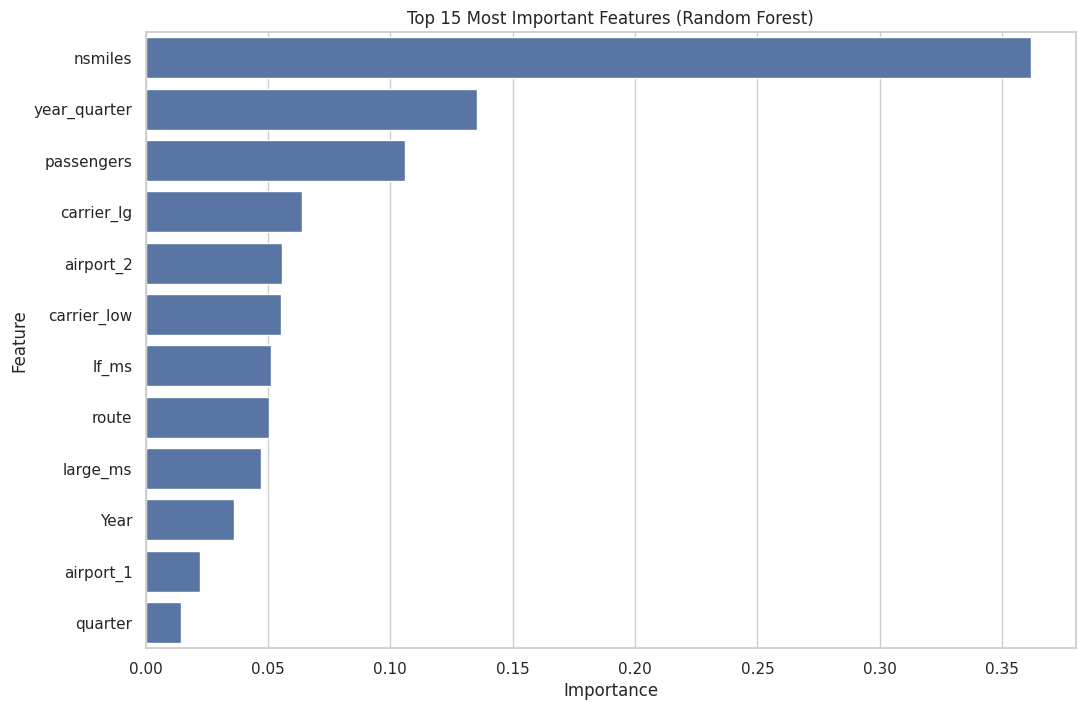

In [70]:
# 1. Compare Model Performance
print("--- Model Comparison ---")
results = {
    'Linear Regression': {'R2': r2_lr, 'MAE': mae_lr, 'RMSE': rmse_lr},
    'Random Forest': {'R2': r2_rf, 'MAE': mae_rf, 'RMSE': rmse_rf},
    'Gradient Boosting': {'R2': r2_gb, 'MAE': mae_gb, 'RMSE': rmse_gb},
    'XGBoost': {'R2': r2_xgb, 'MAE': mae_xgb, 'RMSE': rmse_xgb}
}
results_df = pd.DataFrame(results).T.sort_values(by='R2', ascending=False)
print(results_df)

# 2. Get Feature Importances from the best model (e.g., Random Forest)
print("\n--- Feature Importances (from Random Forest) ---")

# Get the trained Random Forest model from its pipeline
rf_model = rf_pipeline.named_steps['model']
importances = rf_model.feature_importances_

# Get the feature names in the order the preprocessor transformed them
# This is a bit complex but necessary
cat_features = rf_pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(cat_features)

# Create a DataFrame for easy viewing
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display the top 15 most important features
print(importance_df.head(15))

# Plot the top 15 features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title('Top 15 Most Important Features (Random Forest)')
plt.savefig('feature_importance.png')
plt.show()

In [68]:
# --- NEW BLOCK 13: Hyperparameter Tuning for XGBoost ---

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

print("--- Starting Hyperparameter Tuning for XGBoost ---")
print("This may take several minutes...")

# 1. Re-create the XGBoost pipeline
xgb_pipeline_for_tuning = Pipeline(steps=[('preprocessor', preprocessor),
                                          ('model', XGBRegressor(random_state=42, n_jobs=-1))])

# 2. Define a "parameter grid" to search over
param_dist = {
    'model__n_estimators': randint(100, 500),         # Number of trees
    'model__max_depth': randint(3, 10),               # Max depth of each tree
    'model__learning_rate': uniform(0.01, 0.3),     # How fast the model learns
    'model__subsample': uniform(0.7, 0.3)             # % of data used for each tree
}

# 3. Set up the Randomized Search
random_search = RandomizedSearchCV(
    estimator=xgb_pipeline_for_tuning,
    param_distributions=param_dist,
    n_iter=25,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='r2'  # We want to optimize for R-squared
)

# 4. Run the search on your training data
random_search.fit(X_train, y_train)

# 5. Print the best settings found
print("\n--- Best Parameters Found ---")
print(random_search.best_params_)

# 6. Evaluate the new, tuned model on the TEST set
print("\n--- Tuned Model Performance on Test Set ---")
best_model = random_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"Tuned XGBoost R-squared (R2): {r2_tuned:.4f}")
print(f"Tuned XGBoost MAE: {mae_tuned:.4f}")
print(f"Tuned XGBoost RMSE: {rmse_tuned:.4f}")

--- Starting Hyperparameter Tuning for XGBoost ---
This may take several minutes...
Fitting 3 folds for each of 25 candidates, totalling 75 fits

--- Best Parameters Found ---
{'model__learning_rate': np.float64(0.189597545259111), 'model__max_depth': 9, 'model__n_estimators': 221, 'model__subsample': np.float64(0.7467983561008608)}

--- Tuned Model Performance on Test Set ---
Tuned XGBoost R-squared (R2): 0.8281
Tuned XGBoost MAE: 20.1495
Tuned XGBoost RMSE: 30.5800


--- Feature Importances from Tuned XGBoost Model ---
         Feature  Importance
2        nsmiles    0.242759
8     carrier_lg    0.147970
9    carrier_low    0.114114
11  year_quarter    0.102146
3     passengers    0.069384
7      airport_2    0.056845
10         route    0.055425
6      airport_1    0.053756
5          lf_ms    0.052026
0           Year    0.050343
4       large_ms    0.038102
1        quarter    0.017128


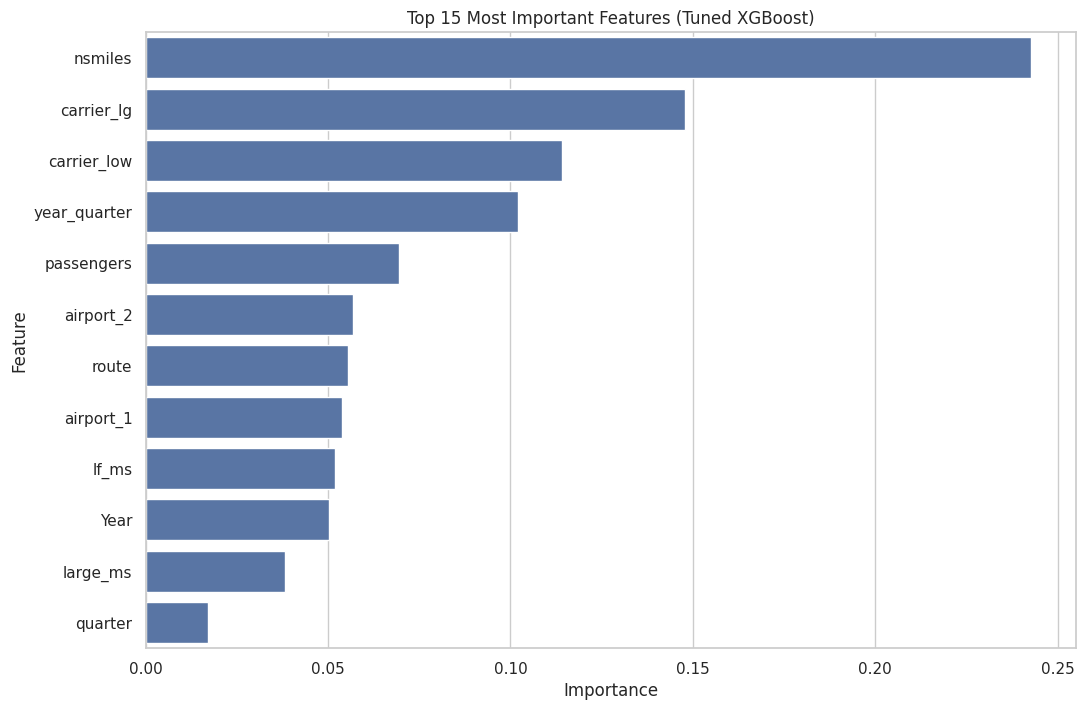

In [69]:
# --- NEW BLOCK 14: Final Feature Importance from Tuned XGBoost ---

print("--- Feature Importances from Tuned XGBoost Model ---")

# 'best_model' is the variable from your tuning block (Block 13)
# It contains the entire pipeline (preprocessor + tuned model)
final_xgb_model = best_model.named_steps['model']
final_preprocessor = best_model.named_steps['preprocessor']

# Get feature names in the correct order
cat_features_final = final_preprocessor.transformers_[1][1].get_feature_names_out(categorical_features)
all_feature_names_final = numerical_features + list(cat_features_final)

# Get importances
importances_final = final_xgb_model.feature_importances_

# Create a DataFrame
importance_df_final = pd.DataFrame({
    'Feature': all_feature_names_final,
    'Importance': importances_final
}).sort_values(by='Importance', ascending=False)

# Display the top 15 most important features
print(importance_df_final.head(15))

# Plot the top 15 features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_final.head(15))
plt.title('Top 15 Most Important Features (Tuned XGBoost)')
plt.savefig('final_feature_importance.png')
plt.show()

In [71]:
# --- NEW BLOCK: Save the Final Model ---
import joblib

# 'best_model' is the variable from your tuning block (Block 13)
# It contains the entire pipeline (preprocessor + tuned model)
model_filename = 'airfare_model_pipeline.joblib'
joblib.dump(best_model, model_filename)

print(f"Model saved successfully as '{model_filename}'")

# You can now download this file from your Colab session

Model saved successfully as 'airfare_model_pipeline.joblib'
